<a href="https://colab.research.google.com/github/amit491/Mutational_order_Cell_state_manuscript/blob/main/scRNASeq/GutAtlas_gene_signatures/ElmDat_inspection_30Mar2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set-up
Note, 'watermark' is being used, instead of relying on 'session_info'

In [ ]:
!pip install scanpy decoupler pydeseq2 watermark

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.1 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=d34a521

In [ ]:
# Import the pkgs
import os
import multiprocessing
import scipy as sp
import scanpy as sc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import decoupler as dc
import pickle as pickle
from google.colab import drive
# For session info
%load_ext watermark

In [ ]:
multiprocessing.cpu_count()

8

In [ ]:
os.getcwd()

'/content'

In [ ]:
drive.mount('/content/my_drive')

Mounted at /content/my_drive


In [ ]:
my_dir = "/content/my_drive/MyDrive/colab_IO/"

In [ ]:
if os.path.exists(os.path.join(my_dir,'GutAtlas.dat/')):
  print('Dir. present!')
else:
  print('Dir. not found!')
#

Dir. present!


# Elm dat // Epi. specific subset

In [ ]:
# Elmentaite et al. Epi. subset dat
Elm_Epi_Nz = sc.read_h5ad(os.path.join(my_dir,"GutAtlas.dat/epi_log_counts02_v2.h5ad"))

In [ ]:
Elm_Epi_Nz

AnnData object with n_obs × n_vars = 142113 × 30282
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'annotation_colors'
    obsm: 'X_pca', 'X_umap'

pseudo-bulking using raw counts, as recommended

In [ ]:
# Elmentaite et al. Epi. subset dat // Raw counts
Elm_Epi_Rx = sc.read_h5ad(os.path.join(my_dir,"GutAtlas.dat/epi_raw_counts02_v2.h5ad"))

In [ ]:
Elm_Epi_Rx

AnnData object with n_obs × n_vars = 142113 × 33538
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types'

In [ ]:
Elm_Epi_Rx.obs.category.value_counts()

,count
category,
Epithelial,142104
Mesenchymal,9


In [ ]:
Elm_Epi_Rx.obs.Diagnosis.value_counts()

,count
Diagnosis,
Healthy adult,77364
fetal,52194
Pediatric healthy,8157
Pediatric Crohn Disease,4398


In [ ]:
Elm_Epi_Rx.obs.Region.value_counts()

,count
Region,
SmallInt,73023
LargeInt,47020
REC,17348
APD,4689
lymph node,33


In [ ]:
Elm_LBowel_Rx = Elm_Epi_Rx[(Elm_Epi_Rx.obs['Region'].isin(['LargeInt','REC'])) &
 (Elm_Epi_Rx.obs['category'] == 'Epithelial') &
  (Elm_Epi_Rx.obs['Diagnosis'].isin(['Healthy adult','fetal','Pediatric healthy']))]

In [ ]:
Elm_LBowel_Rx

View of AnnData object with n_obs × n_vars = 64359 × 33538
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types'

In [ ]:
Elm_LBowel_Rx.obs.category.value_counts()

,count
category,
Epithelial,64359


In [ ]:
Elm_LBowel_Rx.obs.Diagnosis.value_counts()

,count
Diagnosis,
Healthy adult,55960
fetal,8399


In [ ]:
Elm_LBowel_Rx.obs.Region.value_counts()

,count
Region,
LargeInt,47011
REC,17348


In [ ]:
Elm_LBowel_Rx.obs.annotation.value_counts()

,count
annotation,
TA,37248
Colonocyte,13841
BEST4+ epithelial,3367
BEST2+ Goblet cell,2965
Distal progenitor,2585
Stem cells,1068
Goblet cell,972
Enterocyte,791
Proximal progenitor,555


In [ ]:
np.max(Elm_Epi_Rx.X)

np.float32(41487.0)

In [ ]:
np.max(Elm_LBowel_Rx.X)

np.float32(10151.0)

Rather than the 33k genes in the raw data, I am going to subset
it to contain only those that overlap with those in the 'Elm_Epi_Nz'
dataset

In [ ]:
Elm_LBowel_Rx.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [ ]:
Elm_LBowel_Rx.var_names_make_unique()

In [ ]:
Elm_LBowel_Rx.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [ ]:
Elm_Epi_Nz.var_names

Index(['MIR1302-2HG', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL732372.1',
       'AL669831.2', 'AL669831.5', 'FAM87B', 'LINC00115', 'FAM41C',
       ...
       'AC007325.4', 'AC007325.2', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=30282)

In [ ]:
genes_in_Epi_Nz = Elm_Epi_Nz.var_names

In [ ]:
type(genes_in_Epi_Nz)

pandas.core.indexes.base.Index

In [ ]:
len(genes_in_Epi_Nz)

30282

In [ ]:
gene_mask = Elm_LBowel_Rx.var_names.isin(genes_in_Epi_Nz)

In [ ]:
# Checking
np.unique(gene_mask, return_counts=True)

(array([False,  True]), array([ 3275, 30263]))

Subset out to retain only genes that overlap with the 'Nz' set

In [ ]:
Elm_LBowel_Rx_sub = Elm_LBowel_Rx[:,gene_mask].copy()

In [ ]:
Elm_LBowel_Rx_sub

AnnData object with n_obs × n_vars = 64359 × 30263
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'annotation', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types'

In [ ]:
# Clean-up
del genes_in_Epi_Nz
del gene_mask
del Elm_LBowel_Rx

# pseudo-bulking the LBowel set

In [ ]:
Elm_LBowel_Rx_sub.obs.annotation.value_counts().shape

(23,)

In [ ]:
Elm_LBowel_Rx_sub.obs.columns

Index(['Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code',
       'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'doublet_scores', 'predicted_doublets', 'category', 'Age_group',
       'annotation', 'S_score', 'G2M_score', 'phase'],
      dtype='object')

In [ ]:
Elm_LBowel_Rx_sub.obs['Sample name'].value_counts().shape

(22,)

In [ ]:
Elm_LBowel_pB = dc.pp.pseudobulk(
    adata=Elm_LBowel_Rx_sub,
    sample_col="Sample name",
    groups_col="annotation",
    mode="sum",
)

In [ ]:
Elm_LBowel_pB

AnnData object with n_obs × n_vars = 506 × 30263
    obs: 'Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X', 'predicted_doublets', 'category', 'Age_group', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types'
    layers: 'psbulk_props'

In [ ]:
Elm_LBowel_pB.obs.annotation.value_counts().shape

(23,)

In [ ]:
Elm_LBowel_pB.obs.annotation.value_counts()

,count
annotation,
BEST2+ Goblet cell,22
BEST4+ epithelial,22
CLDN10+ cells,22
Colonocyte,22
D cells (SST+),22
Distal progenitor,22
EC cells (NPW+),22
EC cells (TAC1+),22
EECs,22


In [ ]:
Elm_LBowel_pB.obs['Sample name'].value_counts()

,count
Sample name,
A26 (386C),23
A30 (398B),23
A32 (411C),23
A33 (414C),23
A34 (417C),23
A38 (432C),23
A39 (440C),23
BRC2026,23
BRC2029,23


In [ ]:
Elm_LBowel_pB.X.shape

(506, 30263)

In [ ]:
Elm_LBowel_pB.layers['psbulk_props'].shape

(506, 30263)

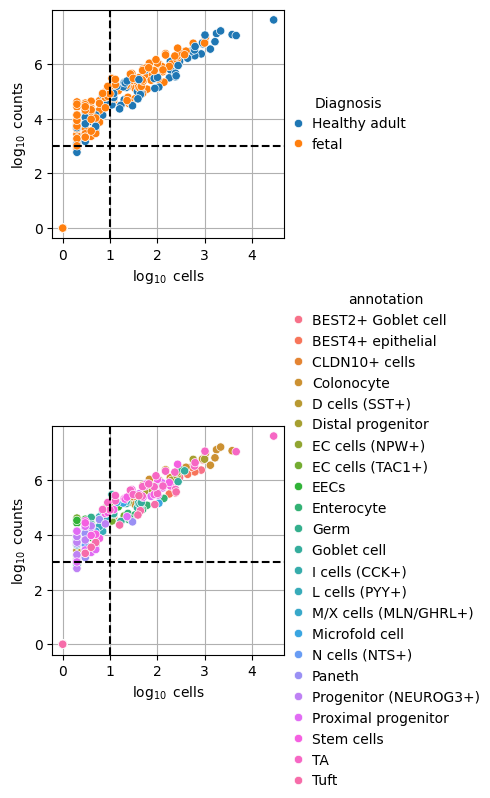

In [ ]:
dc.pl.filter_samples(
    adata=Elm_LBowel_pB,
    groupby=["Diagnosis", "annotation"],
    min_cells=10,
    min_counts=1000,
    figsize=(5, 8),
)

In [ ]:
# This is applying the filter in-place..
dc.pp.filter_samples(Elm_LBowel_pB, min_cells=10, min_counts=1000)

In [ ]:
Elm_LBowel_pB

AnnData object with n_obs × n_vars = 123 × 30263
    obs: 'Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X', 'predicted_doublets', 'category', 'Age_group', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types'
    layers: 'psbulk_props'

In [ ]:
np.max(Elm_LBowel_pB.X)

np.float64(2792350.0)

In [ ]:
Elm_LBowel_pB.obs['Sample name'].value_counts()

,count
Sample name,
F73,11
A26 (386C),8
A33 (414C),8
A38 (432C),8
A39 (440C),8
A30 (398B),8
A34 (417C),7
A32 (411C),7
F66,6


In [ ]:
Elm_LBowel_pB.obs.annotation.value_counts().shape

(17,)

In [ ]:
Elm_LBowel_pB.obs.annotation.value_counts()

,count
annotation,
TA,19
Colonocyte,16
Stem cells,12
Goblet cell,12
BEST4+ epithelial,12
Enterocyte,11
Distal progenitor,9
BEST2+ Goblet cell,7
Proximal progenitor,7


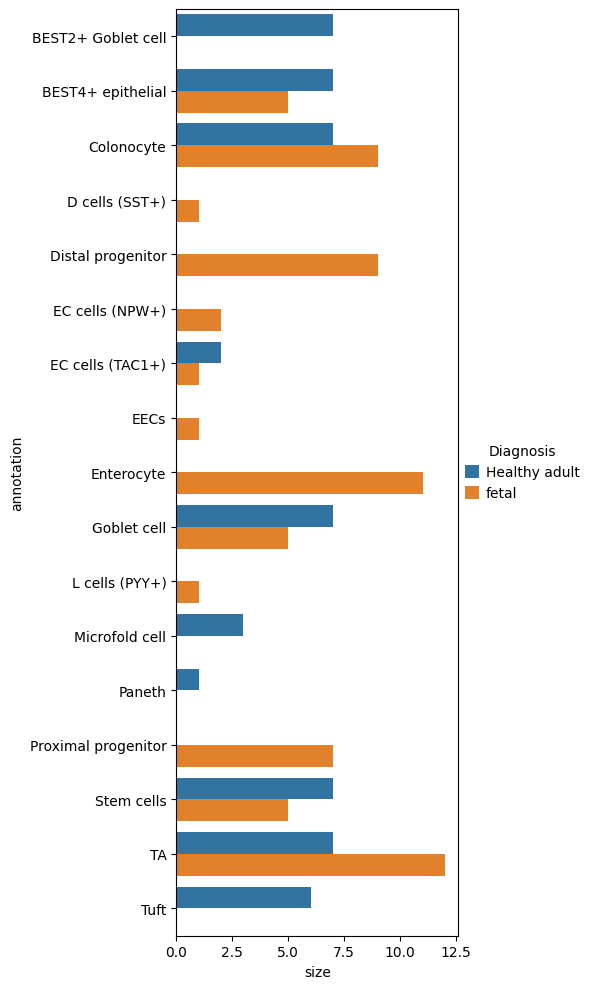

In [ ]:
dc.pl.obsbar(adata=Elm_LBowel_pB, y="annotation", hue="Diagnosis", figsize=(6, 10))

In [ ]:
# Write out the 'LBowel' pseudobulk data
# 30Mar2026
Elm_LBowel_pB.write_h5ad(os.path.join(my_dir,"GutAtlas.dat/Elm_LBowel_pB.h5ad"))

In [ ]:
%watermark -u -n -t -z -m --iversions --jupyter_env

Last updated: Mon, 30 Mar 2026 14:23:35 UTC

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.113+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 8
Architecture: 64bit

decoupler : 2.1.4
google    : 3.0.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
scanpy    : 1.12
scipy     : 1.16.3

Jupyter enviroment: Google Colab

